<a href="https://colab.research.google.com/github/aheliroy-1121/machine_learning_assignment/blob/main/linear_logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1 — Linear Regression
An agricultural research center wants to study the relationship between the amount of fertilizer used and
the crop yield obtained.
Use the following dataset:
Fertilizer (kg/acre) Yield (quintals/acre)
10 12
20 18
30 25
40 31
50 38
60 44
70 50
80 57
90 63
100 70
Task:
Develop a Simple Linear Regression model using Python and scikit-learn to predict crop yield. Your
program should:
1. Load the dataset into a Pandas DataFrame.
2. Perform basic data analysis and check for missing values.
3. Visualize the relationship between fertilizer quantity and yield using a scatter plot.
4. Split the dataset into training and testing sets.
5. Train a Linear Regression model using the training data.
6. Display the coefficient (slope) and intercept of the model.
7. Predict crop yield for the test data.
8. Calculate and display: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared
Error (RMSE), and R² Score.
9. Plot the regression line along with the original data points.
10. Predict the yield for a fertilizer quantity of 65 kg/acre.
11. Explain whether the model provides a good fit based on the obtained evaluation metrics.
Expected Outcome:
A trained Linear Regression model capable of predicting crop yield from fertilizer quantity, along with
appropriate evaluation metrics and graphs.


Dataset:
   Fertilizer  Yield
0          10     12
1          20     18
2          30     25
3          40     31
4          50     38
5          60     44
6          70     50
7          80     57
8          90     63
9         100     70

First five rows:
   Fertilizer  Yield
0          10     12
1          20     18
2          30     25
3          40     31
4          50     38

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Fertilizer  10 non-null     int64
 1   Yield       10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None

Statistical summary:
       Fertilizer      Yield
count   10.000000  10.000000
mean    55.000000  40.800000
std     30.276504  19.452506
min     10.000000  12.000000
25%     32.500000  26.500000
50%     55.000000  41.000000
75%     77.500000  55.250000
max    100.000000  70.000000

Missi

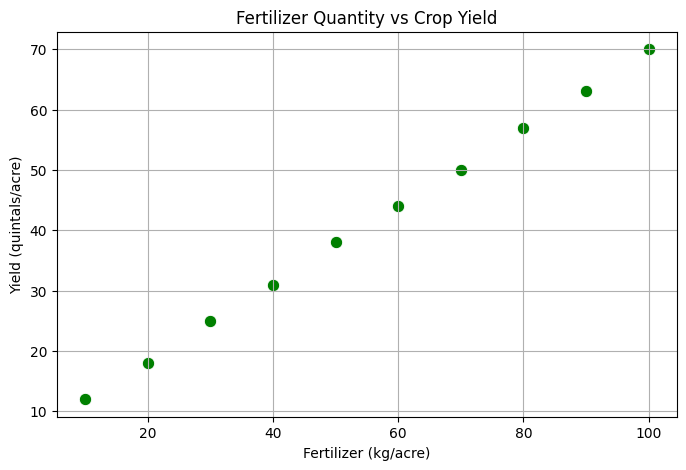


Training data:
   Fertilizer
5          60
0          10
7          80
2          30
9         100
4          50
3          40
6          70

Testing data:
   Fertilizer
8          90
1          20

Model Coefficient (Slope): 0.6422413793103449
Model Intercept: 5.551724137931032

Regression Equation: Yield = 0.6422 * Fertilizer + 5.5517

Actual vs Predicted Yield:
   Fertilizer  Actual Yield  Predicted Yield
0          90            63        63.353448
1          20            18        18.396552

Evaluation Metrics:
Mean Absolute Error (MAE): 0.375
Mean Squared Error (MSE): 0.14108947681331738
Root Mean Squared Error (RMSE): 0.3756187918799023
R² Score: 0.9997213047371589


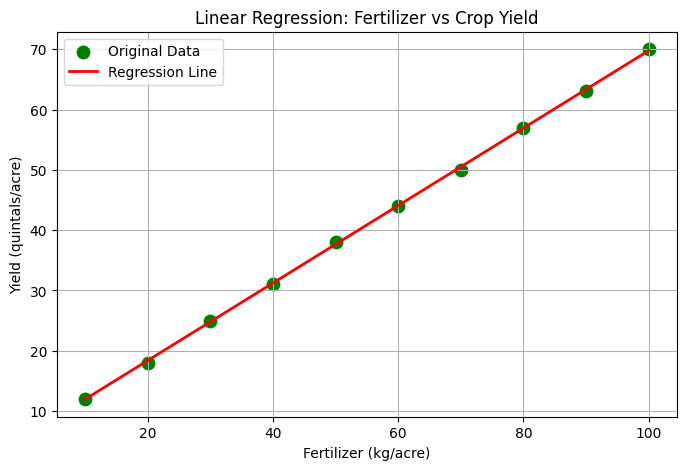


Predicted crop yield for 65 kg/acre: 47.297413793103445 quintals/acre

Model Interpretation:
The model provides a good fit because the R² score is high. The predicted values are close to the actual values.
The positive slope indicates that increasing fertilizer quantity is associated with an increase in crop yield.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
# ============================================
# QUESTION 1: SIMPLE LINEAR REGRESSION
# Fertilizer Quantity vs Crop Yield
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------
# 1. Load the dataset into a Pandas DataFrame
# ------------------------------------------------

data = {
    "Fertilizer": [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    "Yield": [12, 18, 25, 31, 38, 44, 50, 57, 63, 70]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)


# ------------------------------------------------
# 2. Basic data analysis and missing-value check
# ------------------------------------------------

print("\nFirst five rows:")
print(df.head())

print("\nDataset information:")
print(df.info())

print("\nStatistical summary:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())


# ------------------------------------------------
# 3. Scatter plot
# ------------------------------------------------

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="Fertilizer",
    y="Yield",
    data=df,
    s=80,
    color="green"
)

plt.title("Fertilizer Quantity vs Crop Yield")
plt.xlabel("Fertilizer (kg/acre)")
plt.ylabel("Yield (quintals/acre)")
plt.grid(True)
plt.show()


# ------------------------------------------------
# 4. Split dataset into training and testing sets
# ------------------------------------------------

X = df[["Fertilizer"]]
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:")
print(X_train)

print("\nTesting data:")
print(X_test)


# ------------------------------------------------
# 5. Train Linear Regression model
# ------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)


# ------------------------------------------------
# 6. Display coefficient and intercept
# ------------------------------------------------

print("\nModel Coefficient (Slope):", model.coef_[0])
print("Model Intercept:", model.intercept_)

print(
    "\nRegression Equation:"
    f" Yield = {model.coef_[0]:.4f} * Fertilizer + "
    f"{model.intercept_:.4f}"
)


# ------------------------------------------------
# 7. Predict crop yield for test data
# ------------------------------------------------

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Fertilizer": X_test["Fertilizer"].values,
    "Actual Yield": y_test.values,
    "Predicted Yield": y_pred
})

print("\nActual vs Predicted Yield:")
print(results)


# ------------------------------------------------
# 8. Calculate evaluation metrics
# ------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


# ------------------------------------------------
# 9. Plot regression line with original data
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Fertilizer"],
    df["Yield"],
    color="green",
    s=80,
    label="Original Data"
)

plt.plot(
    df["Fertilizer"],
    model.predict(df[["Fertilizer"]]),
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.title("Linear Regression: Fertilizer vs Crop Yield")
plt.xlabel("Fertilizer (kg/acre)")
plt.ylabel("Yield (quintals/acre)")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 10. Predict yield for 65 kg/acre fertilizer
# ------------------------------------------------

fertilizer_value = [[65]]

predicted_yield = model.predict(fertilizer_value)

print(
    "\nPredicted crop yield for 65 kg/acre:",
    predicted_yield[0],
    "quintals/acre"
)


# ------------------------------------------------
# 11. Model interpretation
# ------------------------------------------------

print("\nModel Interpretation:")

if r2 >= 0.80:
    print(
        "The model provides a good fit because the R² score is high. "
        "The predicted values are close to the actual values."
    )
else:
    print(
        "The model may not provide a very strong fit because the R² "
        "score is relatively low."
    )

print(
    "The positive slope indicates that increasing fertilizer quantity "
    "is associated with an increase in crop yield."
)


Question 2 — Multiple Linear Regression
An automobile company wants to predict the fuel efficiency (mileage) of cars based on engine size and car
weight.
Use the following dataset:
Engine Size (L) Weight (kg) Mileage (km/l)
1.0 900 22.5
1.2 950 20.8
1.5 1050 18.2
1.8 1150 16.0
2.0 1250 14.5
2.2 1300 13.2
2.5 1400 12.0
3.0 1550 10.1
3.5 1650 8.8
4.0 1800 7.5
Task:
Develop a Multiple Linear Regression model using Python and scikit-learn to predict mileage from engine
size and weight. Your program should:
1. Load the dataset into a Pandas DataFrame.
2. Perform basic data analysis and check for missing values.
3. Visualize the relationship between each independent variable and mileage using scatter plots.
4. Split the dataset into training and testing sets.
5. Train a Multiple Linear Regression model using engine size and weight as predictors.
6. Display the coefficients and intercept of the model, and interpret their meaning.
7. Predict mileage values for the test data.
8. Calculate and display: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared
Error (RMSE), and R² Score.
9. Plot actual mileage versus predicted mileage.
10. Predict the mileage for a car with an engine size of 2.8 L and weight of 1450 kg.
11. Explain whether the model provides a good fit and which feature has a greater influence on
mileage.
Expected Outcome:
A trained Multiple Linear Regression model capable of predicting car mileage from engine size and
weight, along with appropriate evaluation metrics and graphs

Dataset:
   Engine_Size  Weight  Mileage
0          1.0     900     22.5
1          1.2     950     20.8
2          1.5    1050     18.2
3          1.8    1150     16.0
4          2.0    1250     14.5
5          2.2    1300     13.2
6          2.5    1400     12.0
7          3.0    1550     10.1
8          3.5    1650      8.8
9          4.0    1800      7.5

First five rows:
   Engine_Size  Weight  Mileage
0          1.0     900     22.5
1          1.2     950     20.8
2          1.5    1050     18.2
3          1.8    1150     16.0
4          2.0    1250     14.5

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Engine_Size  10 non-null     float64
 1   Weight       10 non-null     int64  
 2   Mileage      10 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 372.0 bytes

Statistical summary:
       Engine_Size 

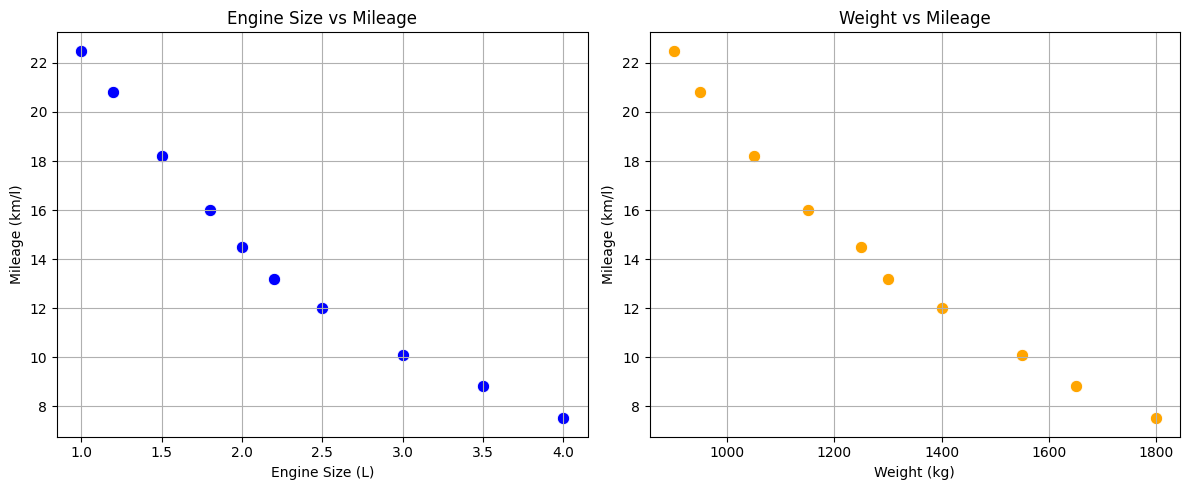


Training data:
   Engine_Size  Weight
5          2.2    1300
0          1.0     900
7          3.0    1550
2          1.5    1050
9          4.0    1800
4          2.0    1250
3          1.8    1150
6          2.5    1400

Testing data:
   Engine_Size  Weight
8          3.5    1650
1          1.2     950

Model Coefficients:
Engine Size coefficient: 8.821973550356054
Weight coefficient: -0.04485045778229908

Model Intercept: 52.706154628687685

Regression Equation: Mileage = 52.7062 + (8.8220 × Engine Size) + (-0.0449 × Weight)

Actual vs Predicted Mileage:
   Engine_Size  Weight  Actual Mileage  Predicted Mileage
8          3.5    1650             8.8           9.579807
1          1.2     950            20.8          20.684588

Evaluation Metrics:
Mean Absolute Error (MAE): 0.44760935910478494
Mean Squared Error (MSE): 0.3107092210508471
Root Mean Squared Error (RMSE): 0.5574129717281856
R² Score: 0.9913691883041431


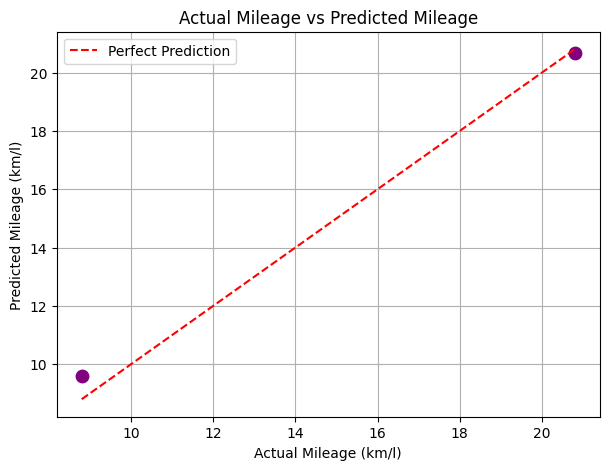


Predicted mileage for a car with 2.8 L engine and 1450 kg weight: 12.374516785350963 km/l

Model Interpretation:
Engine Size coefficient: 8.821973550356054
Weight coefficient: -0.04485045778229908
The negative weight coefficient indicates that, holding engine size constant, heavier cars are associated with lower mileage.
The model provides a good fit because the R² score is high and the prediction errors are relatively small.


In [2]:
# ============================================
# QUESTION 2: MULTIPLE LINEAR REGRESSION
# Engine Size + Weight vs Mileage
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------
# 1. Load dataset into Pandas DataFrame
# ------------------------------------------------

data = {
    "Engine_Size": [1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0, 3.5, 4.0],
    "Weight": [900, 950, 1050, 1150, 1250, 1300, 1400, 1550, 1650, 1800],
    "Mileage": [22.5, 20.8, 18.2, 16.0, 14.5, 13.2, 12.0, 10.1, 8.8, 7.5]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)


# ------------------------------------------------
# 2. Basic data analysis and missing-value check
# ------------------------------------------------

print("\nFirst five rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())


# ------------------------------------------------
# 3. Scatter plots
# ------------------------------------------------

plt.figure(figsize=(12, 5))

# Engine size vs mileage
plt.subplot(1, 2, 1)
sns.scatterplot(
    x="Engine_Size",
    y="Mileage",
    data=df,
    s=80,
    color="blue"
)
plt.title("Engine Size vs Mileage")
plt.xlabel("Engine Size (L)")
plt.ylabel("Mileage (km/l)")
plt.grid(True)

# Weight vs mileage
plt.subplot(1, 2, 2)
sns.scatterplot(
    x="Weight",
    y="Mileage",
    data=df,
    s=80,
    color="orange"
)
plt.title("Weight vs Mileage")
plt.xlabel("Weight (kg)")
plt.ylabel("Mileage (km/l)")
plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 4. Split dataset into training and testing sets
# ------------------------------------------------

X = df[["Engine_Size", "Weight"]]
y = df["Mileage"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:")
print(X_train)

print("\nTesting data:")
print(X_test)


# ------------------------------------------------
# 5. Train Multiple Linear Regression model
# ------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)


# ------------------------------------------------
# 6. Display coefficients and intercept
# ------------------------------------------------

print("\nModel Coefficients:")
print("Engine Size coefficient:", model.coef_[0])
print("Weight coefficient:", model.coef_[1])

print("\nModel Intercept:", model.intercept_)

print(
    "\nRegression Equation:"
    f" Mileage = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f} × Engine Size) "
    f"+ ({model.coef_[1]:.4f} × Weight)"
)


# ------------------------------------------------
# 7. Predict mileage for test data
# ------------------------------------------------

y_pred = model.predict(X_test)

results = X_test.copy()
results["Actual Mileage"] = y_test.values
results["Predicted Mileage"] = y_pred

print("\nActual vs Predicted Mileage:")
print(results)


# ------------------------------------------------
# 8. Calculate evaluation metrics
# ------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


# ------------------------------------------------
# 9. Plot actual vs predicted mileage
# ------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred,
    color="purple",
    s=80
)

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Actual Mileage vs Predicted Mileage")
plt.xlabel("Actual Mileage (km/l)")
plt.ylabel("Predicted Mileage (km/l)")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 10. Predict mileage for 2.8 L and 1450 kg
# ------------------------------------------------

new_car = pd.DataFrame({
    "Engine_Size": [2.8],
    "Weight": [1450]
})

predicted_mileage = model.predict(new_car)

print(
    "\nPredicted mileage for a car with "
    "2.8 L engine and 1450 kg weight:",
    predicted_mileage[0],
    "km/l"
)


# ------------------------------------------------
# 11. Model interpretation
# ------------------------------------------------

print("\nModel Interpretation:")

print(
    "Engine Size coefficient:",
    model.coef_[0]
)

print(
    "Weight coefficient:",
    model.coef_[1]
)

if model.coef_[0] < 0:
    print(
        "The negative engine-size coefficient indicates that, "
        "holding weight constant, larger engines are associated "
        "with lower mileage."
    )

if model.coef_[1] < 0:
    print(
        "The negative weight coefficient indicates that, "
        "holding engine size constant, heavier cars are associated "
        "with lower mileage."
    )

if r2 >= 0.80:
    print(
        "The model provides a good fit because the R² score is high "
        "and the prediction errors are relatively small."
    )
else:
    print(
        "The model may not provide a strong fit because the R² score "
        "is relatively low."
    )

# NOTE:
# Comparing raw coefficient magnitudes directly is not always
# appropriate because Engine_Size and Weight use different units.
# Standardized coefficients would provide a better comparison
# of feature influence.


Question 3 — Logistic Regression
A bank wants to predict whether a customer will default on a loan based on their annual income and credit
score.
Use the following dataset:
Income (■ Lakhs) Credit Score Defaulted (1=Yes, 0=No)
3.5 580 1
4.2 610 1
5.0 650 1
6.1 680 0
7.0 700 0
8.2 720 0
3.0 560 1
9.5 750 0
5.5 630 1
10.0 770 0
4.8 600 1
8.8 740 0
Task:
Develop a Logistic Regression model using Python and scikit-learn to predict loan default. Your program
should:
1. Load the dataset into a Pandas DataFrame.
2. Perform basic data analysis and check for missing values and class balance.
3. Visualize the relationship between income, credit score, and default status using a suitable scatter
plot.
4. Split the dataset into training and testing sets.
5. Train a Logistic Regression model using income and credit score as features.
6. Display the model coefficients and intercept, and interpret their meaning.
7. Predict the default outcome for the test data.
8. Generate and display the confusion matrix.
9. Calculate and display: Accuracy, Precision, Recall, and F1-Score.
10. Plot the ROC curve and calculate the AUC score.
11. Predict whether a customer with an income of ■6.5 Lakhs and a credit score of 660 will default.
12. Explain the model's performance based on the obtained evaluation metrics.
Expected Outcome:
A trained Logistic Regression model capable of classifying customers as likely or unlikely to default, along
with appropriate evaluation metrics and graphs.

Dataset:
    Income  Credit_Score  Defaulted
0      3.5           580          1
1      4.2           610          1
2      5.0           650          1
3      6.1           680          0
4      7.0           700          0
5      8.2           720          0
6      3.0           560          1
7      9.5           750          0
8      5.5           630          1
9     10.0           770          0
10     4.8           600          1
11     8.8           740          0

First five rows:
   Income  Credit_Score  Defaulted
0     3.5           580          1
1     4.2           610          1
2     5.0           650          1
3     6.1           680          0
4     7.0           700          0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Income        12 non-null     float64
 1   Credit_Score  12 non-null     int64  

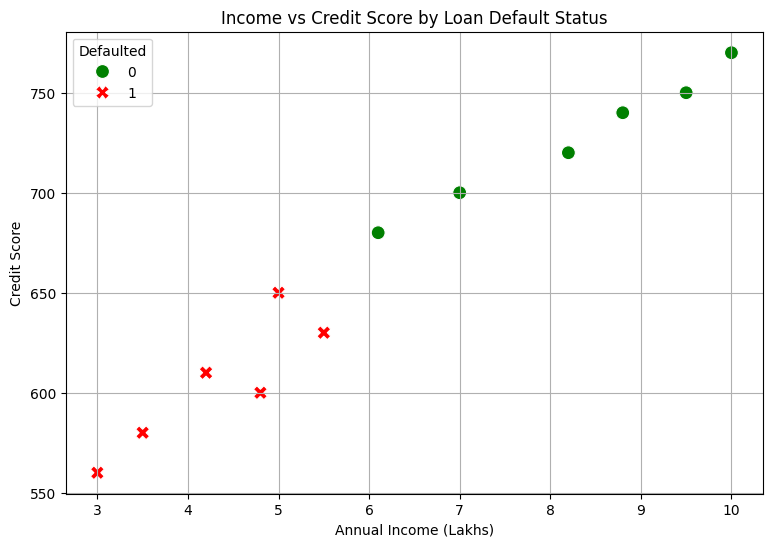


Training samples: 9
Testing samples: 3

Logistic Regression Coefficients:
Income coefficient: -0.9572861589521681
Credit Score coefficient: -0.9980992164125919

Intercept: 0.33364929660366227

Actual vs Predicted:
   Actual  Predicted
0       1          1
1       0          0
2       0          0

Confusion Matrix:
[[2 0]
 [0 1]]


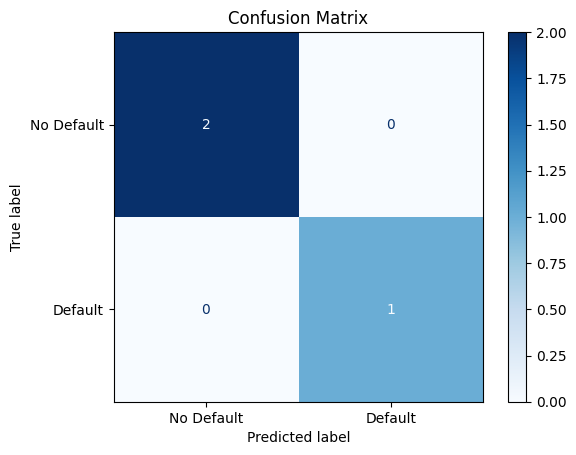


Classification Metrics:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0

AUC Score: 1.0


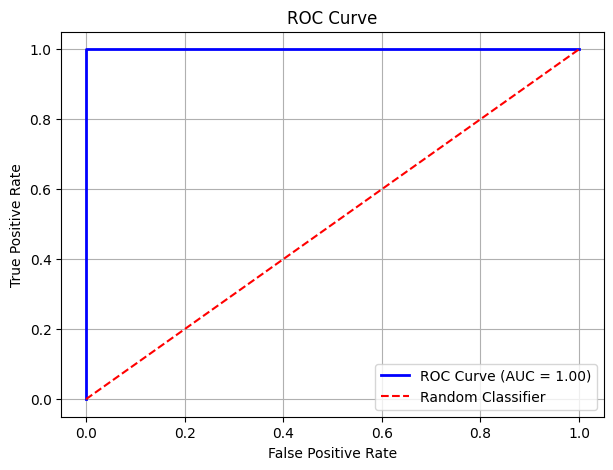


New Customer:
Income: 6.5 Lakhs
Credit Score: 660
Prediction: Customer is NOT likely to DEFAULT.
Probability of default: 0.42928615054933617

Model Interpretation:
Income has a negative coefficient, indicating that higher income is associated with a lower probability of default.
Credit score has a negative coefficient, indicating that higher credit scores are associated with a lower probability of default.

Because the dataset contains only 12 observations, the evaluation metrics should be interpreted cautiously. A larger dataset would provide a more reliable assessment of model performance.


In [3]:
# ============================================
# QUESTION 3: LOGISTIC REGRESSION
# Income + Credit Score vs Loan Default
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)


# ------------------------------------------------
# 1. Load dataset into Pandas DataFrame
# ------------------------------------------------

data = {
    "Income": [3.5, 4.2, 5.0, 6.1, 7.0, 8.2,
               3.0, 9.5, 5.5, 10.0, 4.8, 8.8],

    "Credit_Score": [580, 610, 650, 680, 700, 720,
                     560, 750, 630, 770, 600, 740],

    "Defaulted": [1, 1, 1, 0, 0, 0,
                  1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)


# ------------------------------------------------
# 2. Basic data analysis
# ------------------------------------------------

print("\nFirst five rows:")
print(df.head())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())


# Check class balance
print("\nClass Balance:")
print(df["Defaulted"].value_counts())

print("\nClass Balance in Percentage:")
print(df["Defaulted"].value_counts(normalize=True) * 100)


# ------------------------------------------------
# 3. Scatter plot
# ------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x="Income",
    y="Credit_Score",
    hue="Defaulted",
    style="Defaulted",
    data=df,
    s=100,
    palette={0: "green", 1: "red"}
)

plt.title("Income vs Credit Score by Loan Default Status")
plt.xlabel("Annual Income (Lakhs)")
plt.ylabel("Credit Score")
plt.legend(title="Defaulted")
plt.grid(True)
plt.show()


# ------------------------------------------------
# 4. Split dataset into training and testing sets
# ------------------------------------------------

X = df[["Income", "Credit_Score"]]
y = df["Defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------------
# 5. Feature scaling
# ------------------------------------------------

# Scaling is useful for Logistic Regression because
# Income and Credit Score have very different scales.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------
# 6. Train Logistic Regression model
# ------------------------------------------------

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)


# ------------------------------------------------
# 7. Display coefficients and intercept
# ------------------------------------------------

print("\nLogistic Regression Coefficients:")
print("Income coefficient:", model.coef_[0][0])
print("Credit Score coefficient:", model.coef_[0][1])

print("\nIntercept:", model.intercept_[0])


# ------------------------------------------------
# 8. Predict default outcome
# ------------------------------------------------

y_pred = model.predict(X_test_scaled)

print("\nActual vs Predicted:")
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results)


# ------------------------------------------------
# 9. Confusion Matrix
# ------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# ------------------------------------------------
# 10. Classification metrics
# ------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\nClassification Metrics:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)


# ------------------------------------------------
# 11. ROC Curve and AUC
# ------------------------------------------------

# Probability of class 1 (default)
y_probability = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

print("\nAUC Score:", auc_score)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"ROC Curve (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="red",
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------
# 12. Predict customer with income = 6.5 Lakhs
#     and credit score = 660
# ------------------------------------------------

new_customer = pd.DataFrame({
    "Income": [6.5],
    "Credit_Score": [660]
})

new_customer_scaled = scaler.transform(new_customer)

prediction = model.predict(new_customer_scaled)
probability = model.predict_proba(new_customer_scaled)[0][1]

print("\nNew Customer:")
print("Income: 6.5 Lakhs")
print("Credit Score: 660")

if prediction[0] == 1:
    print("Prediction: Customer is likely to DEFAULT.")
else:
    print("Prediction: Customer is NOT likely to DEFAULT.")

print(
    "Probability of default:",
    probability
)


# ------------------------------------------------
# 13. Model interpretation
# ------------------------------------------------

print("\nModel Interpretation:")

if model.coef_[0][0] < 0:
    print(
        "Income has a negative coefficient, indicating that higher "
        "income is associated with a lower probability of default."
    )
else:
    print(
        "Income has a positive coefficient, indicating that higher "
        "income is associated with a higher probability of default."
    )

if model.coef_[0][1] < 0:
    print(
        "Credit score has a negative coefficient, indicating that "
        "higher credit scores are associated with a lower probability "
        "of default."
    )
else:
    print(
        "Credit score has a positive coefficient, indicating that "
        "higher credit scores are associated with a higher probability "
        "of default."
    )

print(
    "\nBecause the dataset contains only 12 observations, the "
    "evaluation metrics should be interpreted cautiously. A larger "
    "dataset would provide a more reliable assessment of model "
    "performance."
)
